# 📊 Supermarket Sales & Business Analytics
### AICTE | IBM SkillsBuild Data Analytics with AI Internship
- **Author:** Md Sameer Khan
- **Institution:** Maharaja Agrasen Institute of Technology
- **Dataset:** SuperMarket Analysis - Copy.csv
- **Objective:** Exploratory Data Analysis, Revenue Optimization, Customer Segmentation, and Channel Insights

Import Libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 4.5)
print("Libraries imported successfully!")

Libraries imported successfully!


Load & Inspect Dataset

In [37]:
# Load dataset
df = pd.read_csv("SuperMarket Analysis - Copy.csv")

print(f"Total Transactions: {df.shape[0]}")
print(f"Total Features/Columns: {df.shape[1]}")
df.head(5)

Total Transactions: 1000
Total Features/Columns: 17


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


Data Preprocessing & Missing Values Check

In [38]:
# Check for null values
print("Missing values per column:")
print(df.isnull().sum())

# Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Dataset summary statistics
df[['Unit price', 'Quantity', 'Sales', 'Rating']].describe()

Missing values per column:
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64


,Unit price,Quantity,Sales,Rating
count,1000.000000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,322.966749,6.97270
std,26.494628,2.923431,245.885335,1.71858
min,10.080000,1.000000,10.678500,4.00000
25%,32.875000,3.000000,124.422375,5.50000
50%,55.230000,5.000000,253.848000,7.00000
75%,77.935000,8.000000,471.350250,8.50000
max,99.960000,10.000000,1042.650000,10.00000


Core KPI Metrics

In [39]:
total_revenue = df['Sales'].sum()
avg_spend = df['Sales'].mean()
total_tx = len(df)
avg_rating = df['Rating'].mean()

print(f"Total Gross Revenue: ${total_revenue:,.2f}")
print(f"Total Orders: {total_tx:,}")
print(f"Average Spend per Transaction: ${avg_spend:,.2f}")
print(f"Average Customer Satisfaction: {avg_rating:.2f} / 10.0")

Total Gross Revenue: $322,966.75
Total Orders: 1,000
Average Spend per Transaction: $322.97
Average Customer Satisfaction: 6.97 / 10.0


Chart 1: Revenue by Product Line

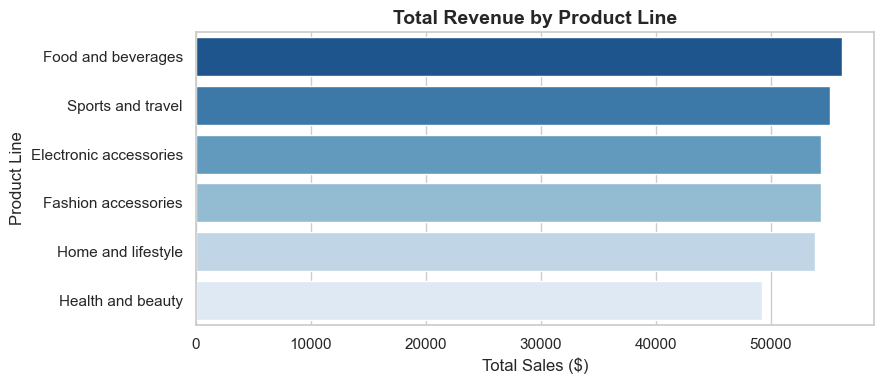

In [40]:
plt.figure(figsize=(9, 4))
cat_sales = df.groupby('Product line')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=cat_sales.values, y=cat_sales.index, hue=cat_sales.index, palette="Blues_r", legend=False)
plt.title("Total Revenue by Product Line", fontsize=14, weight='bold')
plt.xlabel("Total Sales ($)")
plt.ylabel("Product Line")
plt.tight_layout()
plt.show()

Chart 2: Payment Method Breakdown

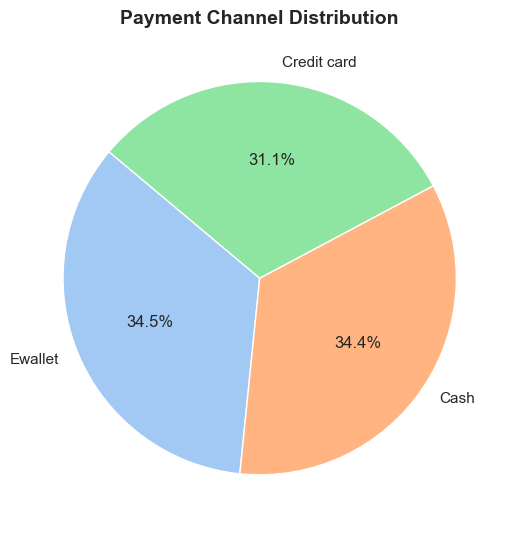

In [41]:
plt.figure(figsize=(5.5, 5.5))
df['Payment'].value_counts().plot(
    kind='pie', 
    autopct='%1.1f%%', 
    colors=sns.color_palette("pastel"), 
    startangle=140
)
plt.title("Payment Channel Distribution", fontsize=14, weight='bold')
plt.ylabel("")
plt.tight_layout()
plt.show()

Chart 3: Store Branch Performance & Customer Spend

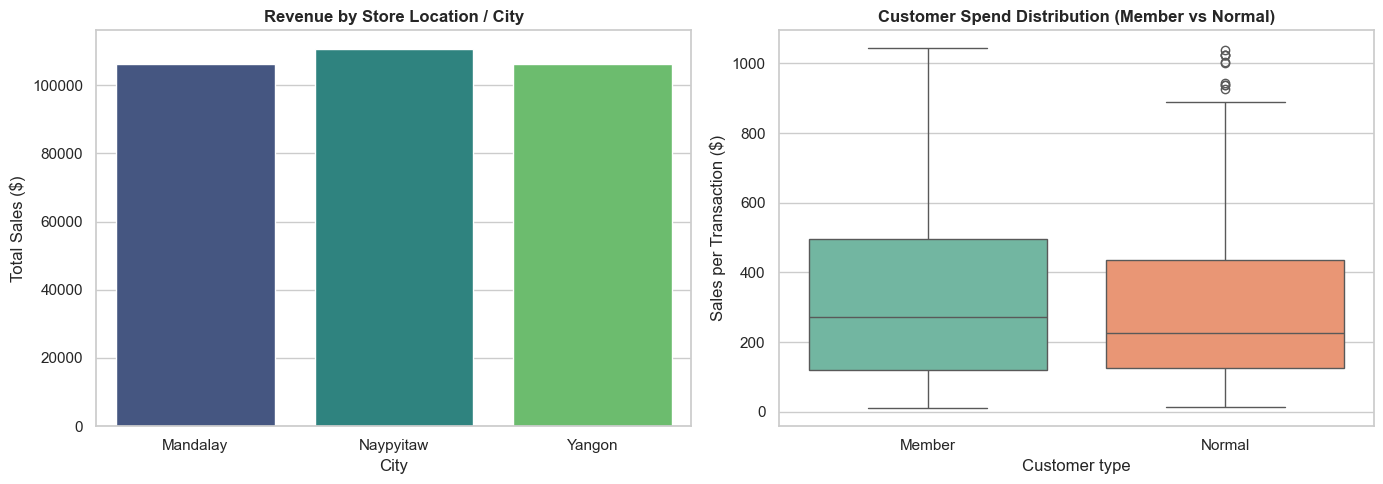

In [42]:
import warnings
warnings.filterwarnings('ignore')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Store Location Revenue
branch_sales = df.groupby('City')['Sales'].sum().reset_index()
sns.barplot(data=branch_sales, x='City', y='Sales', ax=axes[0], palette="viridis")
axes[0].set_title("Revenue by Store Location / City", fontsize=12, weight='bold')
axes[0].set_ylabel("Total Sales ($)")

# Chart 2: Customer Spend Distribution
sns.boxplot(data=df, x='Customer type', y='Sales', ax=axes[1], palette="Set2")
axes[1].set_title("Customer Spend Distribution (Member vs Normal)", fontsize=12, weight='bold')
axes[1].set_ylabel("Sales per Transaction ($)")

plt.tight_layout()
plt.show()